In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [17]:
BASE_DIR = Path("../ollama_outputs")

MODEL_NAME = "qwen2.5-coder-7b"
PROMPTS = ["balanced", "precision", "evidence", "oneVuln"]

MODEL_DIR = BASE_DIR / MODEL_NAME
MODEL_DIR

PosixPath('../ollama_outputs/qwen2.5-coder-7b')

In [18]:
def load_prompt_stats(model_dir: Path, prompt_name: str):
    stats_dir = model_dir / prompt_name / "stats"

    files = {
        "binary_summary": stats_dir / "binary_summary.csv",
        "binary_metrics": stats_dir / "binary_metrics.csv",
        "binary_cm": stats_dir / "binary_confusion_matrix.csv",
        "ovr": stats_dir / "one_vs_rest_metrics.csv",
        "strict_summary": stats_dir / "strict_multiclass_summary.csv",
        "strict_metrics": stats_dir / "strict_multiclass_metrics.csv",
        "strict_cm": stats_dir / "strict_multiclass_confusion_matrix.csv",
    }

    missing = [name for name, path in files.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(f"{prompt_name}: missing files -> {missing}")

    return {
        "prompt": prompt_name,
        "stats_dir": stats_dir,
        "binary_summary": pd.read_csv(files["binary_summary"]),
        "binary_metrics": pd.read_csv(files["binary_metrics"]),
        "binary_cm": pd.read_csv(files["binary_cm"], index_col=0),
        "ovr": pd.read_csv(files["ovr"]),
        "strict_summary": pd.read_csv(files["strict_summary"]),
        "strict_metrics": pd.read_csv(files["strict_metrics"]),
        "strict_cm": pd.read_csv(files["strict_cm"], index_col=0),
    }

In [19]:
runs = []

for prompt in PROMPTS:
    run = load_prompt_stats(MODEL_DIR, prompt)
    runs.append(run)

print(f"Loaded {len(runs)} prompt runs for model: {MODEL_NAME}")

Loaded 4 prompt runs for model: qwen2.5-coder-7b


In [20]:
summary_rows = []

for run in runs:
    prompt = run["prompt"]

    bs = run["binary_summary"].iloc[0]
    ss = run["strict_summary"].iloc[0]
    bm = run["binary_metrics"].copy()

    safe_row = bm[bm["label"] == "SAFE"].iloc[0]
    unsafe_row = bm[bm["label"] == "UNSAFE"].iloc[0]

    summary_rows.append({
        "prompt": prompt,
        "n_rows": int(bs["n_rows"]),
        "binary_accuracy": bs["accuracy"],
        "binary_macro_f1": bs["macro_f1"],
        "safe_precision": safe_row["precision"],
        "safe_recall": safe_row["recall"],
        "safe_f1": safe_row["f1"],
        "unsafe_precision": unsafe_row["precision"],
        "unsafe_recall": unsafe_row["recall"],
        "unsafe_f1": unsafe_row["f1"],
        "strict_accuracy": ss["accuracy"],
        "strict_macro_f1_excl_multi": ss["macro_f1_excluding_multi"],
    })

summary_df = pd.DataFrame(summary_rows).sort_values("binary_macro_f1", ascending=False)
summary_df

,prompt,n_rows,binary_accuracy,binary_macro_f1,safe_precision,safe_recall,safe_f1,unsafe_precision,unsafe_recall,unsafe_f1,strict_accuracy,strict_macro_f1_excl_multi
2,evidence,8251,0.651436,0.642882,0.685973,0.513920,0.587611,0.631839,0.780019,0.698153,0.323112,0.200119
1,precision,8252,0.644450,0.630161,0.699735,0.463274,0.557466,0.618428,0.813981,0.702856,0.307441,0.216660
3,oneVuln,8256,0.620761,0.607689,0.655197,0.453611,0.536079,0.603458,0.776945,0.679299,0.302326,0.210433
0,balanced,8256,0.620155,0.596725,0.687308,0.392329,0.499521,0.594581,0.833138,0.693929,0.265383,0.175993


In [21]:
summary_df_round = summary_df.copy()
for col in summary_df_round.columns:
    if col != "prompt" and col != "n_rows":
        summary_df_round[col] = summary_df_round[col].round(3)

summary_df_round

,prompt,n_rows,binary_accuracy,binary_macro_f1,safe_precision,safe_recall,safe_f1,unsafe_precision,unsafe_recall,unsafe_f1,strict_accuracy,strict_macro_f1_excl_multi
2,evidence,8251,0.651,0.643,0.686,0.514,0.588,0.632,0.780,0.698,0.323,0.200
1,precision,8252,0.644,0.630,0.700,0.463,0.557,0.618,0.814,0.703,0.307,0.217
3,oneVuln,8256,0.621,0.608,0.655,0.454,0.536,0.603,0.777,0.679,0.302,0.210
0,balanced,8256,0.620,0.597,0.687,0.392,0.500,0.595,0.833,0.694,0.265,0.176


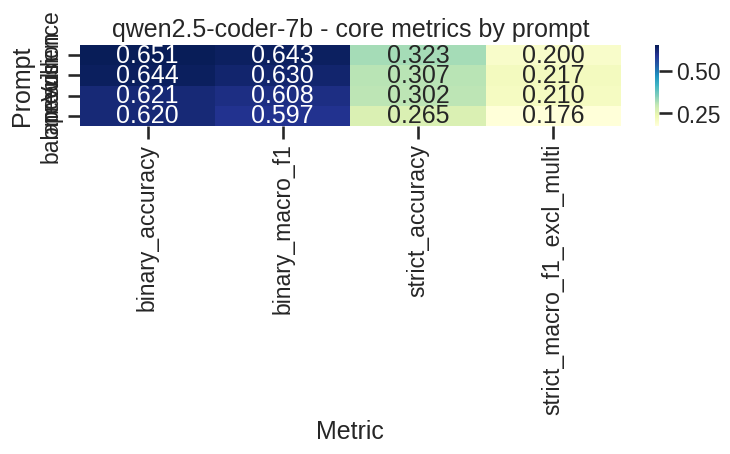

In [22]:
metric_heatmap = summary_df.set_index("prompt")[
    ["binary_accuracy", "binary_macro_f1", "strict_accuracy", "strict_macro_f1_excl_multi"]
]

plt.figure(figsize=(8, 4.8))
sns.heatmap(metric_heatmap, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title(f"{MODEL_NAME} - core metrics by prompt")
plt.xlabel("Metric")
plt.ylabel("Prompt")
plt.tight_layout()
plt.savefig("../Graphs/qwen2.5-coder:7b/core_metrics_by_prompt", dpi=300, bbox_inches="tight")
plt.show()

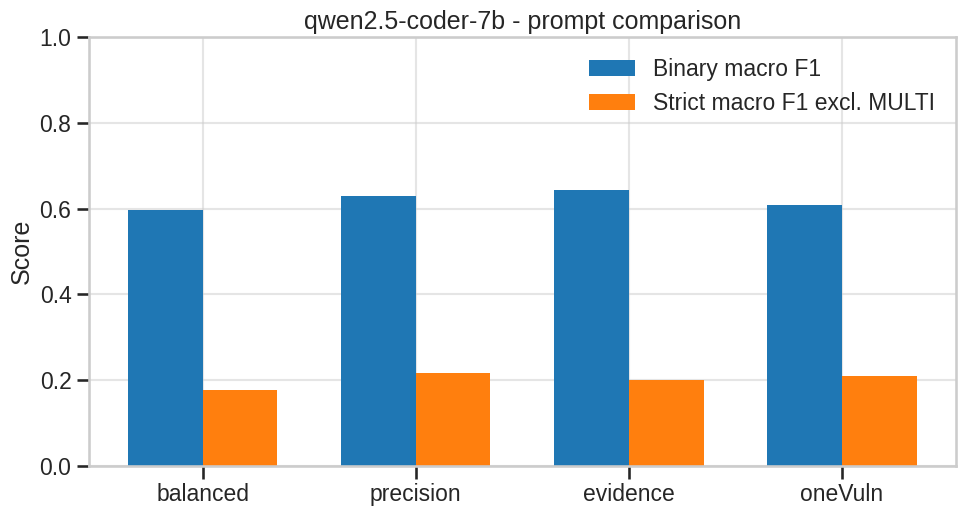

In [23]:
plot_df = summary_df.set_index("prompt").loc[PROMPTS].reset_index()
x = np.arange(len(plot_df))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, plot_df["binary_macro_f1"], width=w, label="Binary macro F1", color="#1f77b4")
ax.bar(x + w/2, plot_df["strict_macro_f1_excl_multi"], width=w, label="Strict macro F1 excl. MULTI", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["prompt"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title(f"{MODEL_NAME} - prompt comparison")
ax.legend()

plt.tight_layout()
plt.savefig("../Graphs/qwen2.5-coder:7b/prompt_comparison", dpi=300, bbox_inches="tight")
plt.show()

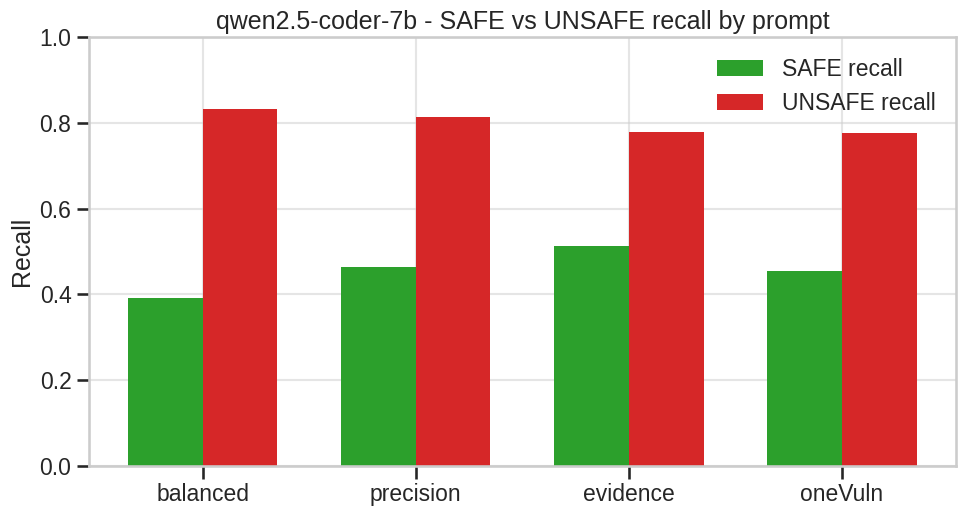

In [24]:
recall_df = summary_df.set_index("prompt")[["safe_recall", "unsafe_recall"]].loc[PROMPTS]
x = np.arange(len(recall_df))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - w/2, recall_df["safe_recall"], width=w, label="SAFE recall", color="#2ca02c")
ax.bar(x + w/2, recall_df["unsafe_recall"], width=w, label="UNSAFE recall", color="#d62728")

ax.set_xticks(x)
ax.set_xticklabels(recall_df.index)
ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title(f"{MODEL_NAME} - SAFE vs UNSAFE recall by prompt")
ax.legend()

plt.tight_layout()
plt.savefig("../Graphs/qwen2.5-coder:7b/SAFE_vs_UNSAFE_recall_by_prompt", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
strict_f1_rows = []

for run in runs:
    prompt = run["prompt"]
    sm = run["strict_metrics"].copy()
    sm = sm[sm["label"] != "MULTI"]

    for _, row in sm.iterrows():
        strict_f1_rows.append({
            "prompt": prompt,
            "label": row["label"],
            "f1": row["f1"],
            "support": row["support"]
        })

strict_f1_df = pd.DataFrame(strict_f1_rows)
strict_f1_df.head()

,prompt,label,f1,support
0,balanced,SAFE,0.500000,3989
1,balanced,BN,0.228464,405
2,balanced,DE,0.115702,97
3,balanced,EF,0.000000,97
4,balanced,OF,0.242768,588


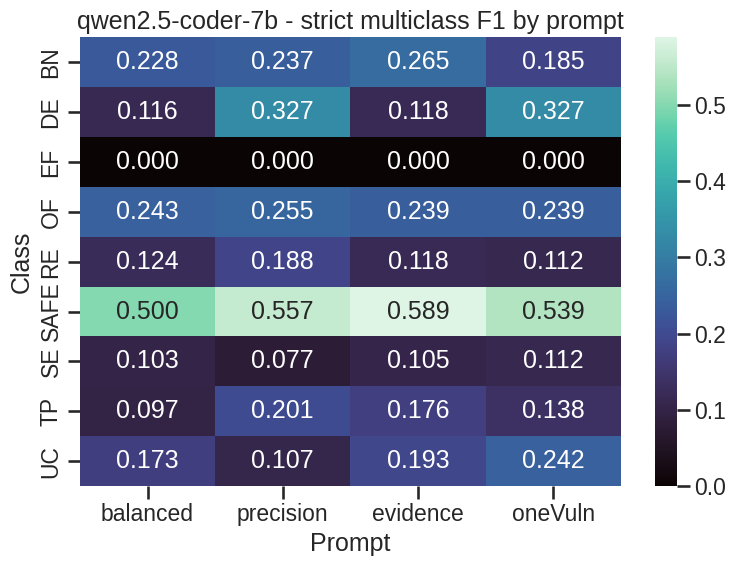

In [26]:
strict_f1_pivot = strict_f1_df.pivot(index="label", columns="prompt", values="f1").reindex(columns=PROMPTS)
plt.figure(figsize=(8, 6))
sns.heatmap(strict_f1_pivot, annot=True, fmt=".3f", cmap="mako")
plt.title(f"{MODEL_NAME} - strict multiclass F1 by prompt")
plt.xlabel("Prompt")
plt.ylabel("Class")
plt.tight_layout()
plt.savefig("../Graphs/qwen2.5-coder:7b/strict_multiclass_F1_by_prompt", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
ovr_rows = []

for run in runs:
    prompt = run["prompt"]
    ovr = run["ovr"].copy()

    for _, row in ovr.iterrows():
        ovr_rows.append({
            "prompt": prompt,
            "label": row["label"],
            "precision": row["positive_class_precision"],
            "recall": row["positive_class_recall"],
            "f1": row["positive_class_f1"],
            "support_positive": row["support_positive"]
        })

ovr_df = pd.DataFrame(ovr_rows)
ovr_df.head()

,prompt,label,precision,recall,f1,support_positive
0,balanced,BN,0.525210,0.308642,0.388802,405
1,balanced,DE,0.282051,0.907216,0.430318,97
2,balanced,EF,0.000000,0.000000,0.000000,97
3,balanced,SE,0.225275,0.112329,0.149909,365
4,balanced,OF,0.198191,0.409864,0.267184,588


In [28]:
best_per_prompt = (
    ovr_df.sort_values(["prompt", "f1"], ascending=[True, False])
          .groupby("prompt", as_index=False)
          .first()[["prompt", "label", "precision", "recall", "f1", "support_positive"]]
)

best_per_prompt = best_per_prompt.sort_values("f1", ascending=False)
best_per_prompt.round(3)

,prompt,label,precision,recall,f1,support_positive
1,evidence,UC,0.574,0.717,0.638,1192
2,oneVuln,UC,0.552,0.657,0.600,1194
0,balanced,UC,0.502,0.720,0.592,1193
3,precision,UC,0.556,0.626,0.589,1191


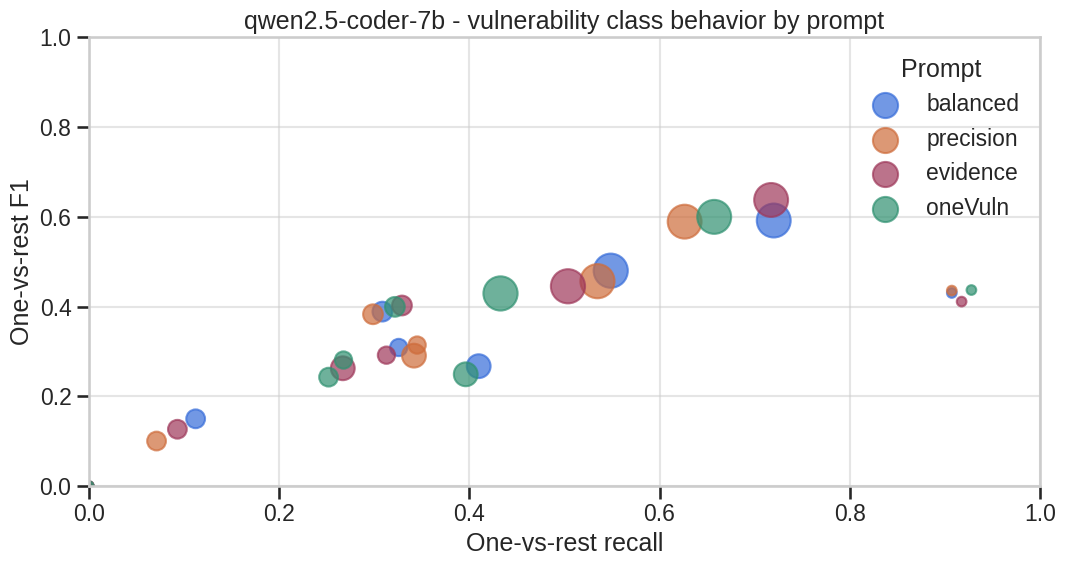

In [29]:
fig, ax = plt.subplots(figsize=(11, 6))

for prompt in PROMPTS:
    subset = ovr_df[ovr_df["prompt"] == prompt]
    ax.scatter(
        subset["recall"],
        subset["f1"],
        s=subset["support_positive"] * 0.5,
        alpha=0.7,
        label=prompt
    )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("One-vs-rest recall")
ax.set_ylabel("One-vs-rest F1")
ax.set_title(f"{MODEL_NAME} - vulnerability class behavior by prompt")
ax.legend(title="Prompt")

plt.tight_layout()
plt.savefig("../Graphs/qwen2.5-coder:7b/vulnerability_class_behavior_by_prompt", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
summary_df_round.to_csv(MODEL_DIR / f"{MODEL_NAME.replace(':', '_')}_prompt_summary.csv", index=False)
strict_f1_df.to_csv(MODEL_DIR / f"{MODEL_NAME.replace(':', '_')}_strict_f1_by_prompt.csv", index=False)
ovr_df.to_csv(MODEL_DIR / f"{MODEL_NAME.replace(':', '_')}_ovr_by_prompt.csv", index=False)

print("Saved summary CSV files in:")
print(MODEL_DIR)

Saved summary CSV files in:
../ollama_outputs/qwen2.5-coder-7b
